In [2]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# =========================
# 1) Parámetros generales
# =========================
fecha_fin = "2026-03-02"

# Puedes cambiar esto si tu profe quiere más o menos historia.
# 800 días calendario suelen cubrir bien más de 500 observaciones hábiles.
dias_historia = 1000
fecha_inicio = (datetime.strptime(fecha_fin, "%Y-%m-%d") - timedelta(days=dias_historia)).strftime("%Y-%m-%d")

archivo_salida = "portafolios_riesgo_mercado_CHF.xlsx"

# =========================
# 2) Tickers de Yahoo Finance
# =========================
# Índices
indices = {
    "NIKKEI225": "^N225",      # Japón
    "HANG_SENG": "^HSI",       # Hong Kong
    "SHENZHEN": "399001.SZ",   # China
    "SP_ASX200": "^AXJO",      # Australia
    "SP500": "^GSPC",          # EUA
    "DAX": "^GDAXI",           # Alemania
    "FTSE100": "^FTSE"         # Reino Unido
}

# Tipos de cambio a CHF
fx = {
    "JPYCHF": "JPYCHF=X",
    "HKDCHF": "HKDCHF=X",
    "CNYCHF": "CNYCHF=X",
    "AUDCHF": "AUDCHF=X",
    "USDCHF": "USDCHF=X",
    "EURCHF": "EURCHF=X",
    "GBPCHF": "GBPCHF=X"
}

# Relación índice -> FX correspondiente
mapa_fx = {
    "NIKKEI225": "JPYCHF",
    "HANG_SENG": "HKDCHF",
    "SHENZHEN": "CNYCHF",
    "SP_ASX200": "AUDCHF",
    "SP500": "USDCHF",
    "DAX": "EURCHF",
    "FTSE100": "GBPCHF"
}

# =========================
# 3) Función para descargar
# =========================
def descargar_adj_close(tickers_dict, start, end):
    """
    Descarga Adj Close si existe; si no, usa Close.
    Regresa DataFrame con columnas renombradas usando las llaves del diccionario.
    """
    tickers = list(tickers_dict.values())

    data = yf.download(
        tickers=tickers,
        start=start,
        end=(datetime.strptime(end, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True
    )

    resultado = pd.DataFrame()

    for nombre, ticker in tickers_dict.items():
        try:
            # Caso multi-index
            if (ticker, "Adj Close") in data.columns:
                serie = data[(ticker, "Adj Close")].copy()
            elif (ticker, "Close") in data.columns:
                serie = data[(ticker, "Close")].copy()
            else:
                raise KeyError(f"No se encontró ni Adj Close ni Close para {ticker}")
        except Exception:
            # Caso columnas simples si solo baja una serie
            if "Adj Close" in data.columns:
                serie = data["Adj Close"].copy()
            elif "Close" in data.columns:
                serie = data["Close"].copy()
            else:
                raise KeyError(f"No se pudo encontrar columna de precios para {ticker}")

        resultado[nombre] = serie

    resultado.index = pd.to_datetime(resultado.index)
    resultado = resultado.sort_index()
    return resultado

# =========================
# 4) Descargar datos
# =========================
print("Descargando índices...")
df_indices = descargar_adj_close(indices, fecha_inicio, fecha_fin)

print("Descargando tipos de cambio...")
df_fx = descargar_adj_close(fx, fecha_inicio, fecha_fin)

# =========================
# 5) Alinear fechas
# =========================
# Unimos por índice de fechas
df_base = pd.concat([df_indices, df_fx], axis=1).sort_index()

# Si quieres conservar solo fechas donde haya todos los datos:
df_base = df_base.dropna(how="any").copy()

# =========================
# Limpieza de outliers en FX
# =========================
fx_cols = ["JPYCHF", "HKDCHF", "CNYCHF", "AUDCHF", "USDCHF", "EURCHF", "GBPCHF"]

for col in fx_cols:
    rend_fx = df_base[col].pct_change()
    mask_outlier = rend_fx.abs() > 0.05  # umbral de 5%
    
    if mask_outlier.any():
        print(f"Outliers detectados en {col}:")
        print(df_base.loc[mask_outlier, [col]])
        
        df_base.loc[mask_outlier, col] = pd.NA
        df_base[col] = df_base[col].interpolate()

# =========================
# 6) Convertir índices a CHF
# =========================
df_chf = pd.DataFrame(index=df_base.index)

for activo in indices.keys():
    fx_name = mapa_fx[activo]
    df_chf[activo + "_CHF"] = df_base[activo] * df_base[fx_name]

# =========================
# 7) Construir portafolios
# =========================
# Pesos / participaciones en millones CHF
# Portafolio 1
w1 = {
    "NIKKEI225_CHF": 0.15,
    "HANG_SENG_CHF": 0.20,
    "SHENZHEN_CHF": 0.25,
    "SP_ASX200_CHF": 0.40
}

# Portafolio 2
w2 = {
    "SP500_CHF": 0.15,
    "DAX_CHF": 0.20,
    "FTSE100_CHF": 0.25,
    "NIKKEI225_CHF": 0.40
}

# Normalizamos cada serie para crear un índice de valor del portafolio
# Esto sirve para ver evolución comparativa.
df_port = pd.DataFrame(index=df_chf.index)

for col in df_chf.columns:
    df_port[col] = df_chf[col] / df_chf[col].iloc[0]

df_port["PORTAFOLIO_1_INDICE"] = (
    w1["NIKKEI225_CHF"] * df_port["NIKKEI225_CHF"] +
    w1["HANG_SENG_CHF"] * df_port["HANG_SENG_CHF"] +
    w1["SHENZHEN_CHF"] * df_port["SHENZHEN_CHF"] +
    w1["SP_ASX200_CHF"] * df_port["SP_ASX200_CHF"]
)

df_port["PORTAFOLIO_2_INDICE"] = (
    w2["SP500_CHF"] * df_port["SP500_CHF"] +
    w2["DAX_CHF"] * df_port["DAX_CHF"] +
    w2["FTSE100_CHF"] * df_port["FTSE100_CHF"] +
    w2["NIKKEI225_CHF"] * df_port["NIKKEI225_CHF"]
)

# Si quieres valor monetario suponiendo 100 millones CHF iniciales:
valor_inicial = 100_000_000
df_port["PORTAFOLIO_1_VALOR_CHF"] = valor_inicial * df_port["PORTAFOLIO_1_INDICE"]
df_port["PORTAFOLIO_2_VALOR_CHF"] = valor_inicial * df_port["PORTAFOLIO_2_INDICE"]

# =========================
# 8) Rendimientos diarios
# =========================
df_rend = df_chf.pct_change().dropna().copy()

df_rend["PORTAFOLIO_1_REND"] = (
    w1["NIKKEI225_CHF"] * df_rend["NIKKEI225_CHF"] +
    w1["HANG_SENG_CHF"] * df_rend["HANG_SENG_CHF"] +
    w1["SHENZHEN_CHF"] * df_rend["SHENZHEN_CHF"] +
    w1["SP_ASX200_CHF"] * df_rend["SP_ASX200_CHF"]
)

df_rend["PORTAFOLIO_2_REND"] = (
    w2["SP500_CHF"] * df_rend["SP500_CHF"] +
    w2["DAX_CHF"] * df_rend["DAX_CHF"] +
    w2["FTSE100_CHF"] * df_rend["FTSE100_CHF"] +
    w2["NIKKEI225_CHF"] * df_rend["NIKKEI225_CHF"]
)

# =========================
# 9) Estadísticas descriptivas
# =========================
estadisticas = df_rend.describe().T
estadisticas["skew"] = df_rend.skew()
estadisticas["kurtosis"] = df_rend.kurtosis()

# =========================
# 10) Guardar en Excel
# =========================
with pd.ExcelWriter(archivo_salida, engine="openpyxl") as writer:
    df_indices.to_excel(writer, sheet_name="Indices_Local")
    df_fx.to_excel(writer, sheet_name="FX_CHF")
    df_base.to_excel(writer, sheet_name="Base_Alineada")
    df_chf.to_excel(writer, sheet_name="Indices_CHF")
    df_port.to_excel(writer, sheet_name="Portafolios")
    df_rend.to_excel(writer, sheet_name="Rendimientos")
    estadisticas.to_excel(writer, sheet_name="Estadisticas")

print(f"Archivo Excel generado correctamente: {archivo_salida}")
print(f"Periodo descargado: {fecha_inicio} a {fecha_fin}")
print(f"Última fecha disponible en la base alineada: {df_base.index.max().date() if not df_base.empty else 'Sin datos'}")

Descargando índices...


c:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
c:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Descargando tipos de cambio...


c:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
C:\Users\pedro\AppData\Local\Temp\ipykernel_5904\551627195.py:112: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_base = pd.concat([df_indices, df_fx], axis=1).sort_index()


Outliers detectados en CNYCHF:
              CNYCHF
Date                
2025-04-15  0.214458
2025-04-16  0.111684
Outliers detectados en AUDCHF:
             AUDCHF
Date               
2025-04-07  0.50982
Archivo Excel generado correctamente: portafolios_riesgo_mercado_CHF.xlsx
Periodo descargado: 2023-06-06 a 2026-03-02
Última fecha disponible en la base alineada: 2026-03-02


In [4]:
import numpy as np
# Valor actual de cada portafolio
V0 = 100_000_000
alpha = 0.975

# Rendimientos diarios
r1 = df_rend["PORTAFOLIO_1_REND"].dropna().copy()
r2 = df_rend["PORTAFOLIO_2_REND"].dropna().copy()

def var_cvar_historico(rendimientos, V0=100_000_000, alpha=0.975):
    # Pérdidas monetarias
    perdidas = -V0 * rendimientos
    
    # VaR histórico
    var = np.quantile(perdidas, alpha)
    
    # CVaR histórico
    cvar = perdidas[perdidas >= var].mean()
    
    return var, cvar, perdidas

# 1 día
var1_1d, cvar1_1d, perdidas1_1d = var_cvar_historico(r1, V0, alpha)
var2_1d, cvar2_1d, perdidas2_1d = var_cvar_historico(r2, V0, alpha)

print("Portafolio 1 - Histórico 1 día")
print("VaR:", var1_1d)
print("CVaR:", cvar1_1d)

print("\nPortafolio 2 - Histórico 1 día")
print("VaR:", var2_1d)
print("CVaR:", cvar2_1d)

Portafolio 1 - Histórico 1 día
VaR: 2199288.2484234525
CVaR: 3432615.8617155636

Portafolio 2 - Histórico 1 día
VaR: 1775895.9103257714
CVaR: 3302277.507886322


In [5]:
def rendimiento_acumulado_10d(r):
    return (1 + r).rolling(10).apply(np.prod, raw=True) - 1

r1_10d = rendimiento_acumulado_10d(r1).dropna()
r2_10d = rendimiento_acumulado_10d(r2).dropna()

var1_10d, cvar1_10d, perdidas1_10d = var_cvar_historico(r1_10d, V0, alpha)
var2_10d, cvar2_10d, perdidas2_10d = var_cvar_historico(r2_10d, V0, alpha)

print("\nPortafolio 1 - Histórico 10 días")
print("VaR:", var1_10d)
print("CVaR:", cvar1_10d)

print("\nPortafolio 2 - Histórico 10 días")
print("VaR:", var2_10d)
print("CVaR:", cvar2_10d)


Portafolio 1 - Histórico 10 días
VaR: 6314962.352130587
CVaR: 10630079.44586163

Portafolio 2 - Histórico 10 días
VaR: 5728287.650737114
CVaR: 9970722.683017818


In [6]:
V0 = 100_000_000
alpha = 0.975
n_sim = 100000
np.random.seed(123)

r1 = df_rend["PORTAFOLIO_1_REND"].dropna().copy()
r2 = df_rend["PORTAFOLIO_2_REND"].dropna().copy()

def var_cvar_montecarlo(rendimientos, V0=100_000_000, alpha=0.975, n_sim=100000, horizonte=1):
    mu = rendimientos.mean()
    sigma = rendimientos.std()

    # Parámetros ajustados al horizonte
    mu_h = mu * horizonte
    sigma_h = sigma * np.sqrt(horizonte)

    # Simulación normal
    sim_r = np.random.normal(loc=mu_h, scale=sigma_h, size=n_sim)

    # Pérdidas monetarias
    perdidas = -V0 * sim_r

    # VaR y CVaR
    var = np.quantile(perdidas, alpha)
    cvar = perdidas[perdidas >= var].mean()

    return var, cvar, sim_r, perdidas, mu, sigma

# Portafolio 1
var1_mc_1d, cvar1_mc_1d, sim_r1_1d, perd1_1d, mu1, sigma1 = var_cvar_montecarlo(
    r1, V0=V0, alpha=alpha, n_sim=n_sim, horizonte=1
)

var1_mc_10d, cvar1_mc_10d, sim_r1_10d, perd1_10d, _, _ = var_cvar_montecarlo(
    r1, V0=V0, alpha=alpha, n_sim=n_sim, horizonte=10
)

# Portafolio 2
var2_mc_1d, cvar2_mc_1d, sim_r2_1d, perd2_1d, mu2, sigma2 = var_cvar_montecarlo(
    r2, V0=V0, alpha=alpha, n_sim=n_sim, horizonte=1
)

var2_mc_10d, cvar2_mc_10d, sim_r2_10d, perd2_10d, _, _ = var_cvar_montecarlo(
    r2, V0=V0, alpha=alpha, n_sim=n_sim, horizonte=10
)

print("Portafolio 1 - Monte Carlo 1 día")
print("Media diaria:", mu1)
print("Volatilidad diaria:", sigma1)
print("VaR:", var1_mc_1d)
print("CVaR:", cvar1_mc_1d)

print("\nPortafolio 2 - Monte Carlo 1 día")
print("Media diaria:", mu2)
print("Volatilidad diaria:", sigma2)
print("VaR:", var2_mc_1d)
print("CVaR:", cvar2_mc_1d)

print("\nPortafolio 1 - Monte Carlo 10 días")
print("VaR:", var1_mc_10d)
print("CVaR:", cvar1_mc_10d)

print("\nPortafolio 2 - Monte Carlo 10 días")
print("VaR:", var2_mc_10d)
print("CVaR:", cvar2_mc_10d)

Portafolio 1 - Monte Carlo 1 día
Media diaria: 0.00042455425634994637
Volatilidad diaria: 0.011573698639512834
VaR: 2212651.560289317
CVaR: 2652681.085289065

Portafolio 2 - Monte Carlo 1 día
Media diaria: 0.0006182608995646681
Volatilidad diaria: 0.01055158183492946
VaR: 1997688.9103813139
CVaR: 2399081.8450957895

Portafolio 1 - Monte Carlo 10 días
VaR: 6726404.3121800395
CVaR: 8125318.04418272

Portafolio 2 - Monte Carlo 10 días
VaR: 5942520.447479868
CVaR: 7182998.830412802


In [8]:
from scipy.stats import norm
V0 = 100_000_000
alpha = 0.975
z = norm.ppf(alpha)
phi_z = norm.pdf(z)

# Parámetros ya estimados
mu1 = r1.mean()
sigma1 = r1.std()

mu2 = r2.mean()
sigma2 = r2.std()

def var_cvar_parametrico(mu, sigma, V0=100_000_000, alpha=0.975, horizonte=1):
    z = norm.ppf(alpha)
    phi_z = norm.pdf(z)
    
    mu_h = mu * horizonte
    sigma_h = sigma * np.sqrt(horizonte)
    
    var = V0 * (z * sigma_h - mu_h)
    cvar = V0 * ((phi_z / (1 - alpha)) * sigma_h - mu_h)
    
    return var, cvar

# Portafolio 1
var1_p_1d, cvar1_p_1d = var_cvar_parametrico(mu1, sigma1, V0, alpha, horizonte=1)
var1_p_10d, cvar1_p_10d = var_cvar_parametrico(mu1, sigma1, V0, alpha, horizonte=10)

# Portafolio 2
var2_p_1d, cvar2_p_1d = var_cvar_parametrico(mu2, sigma2, V0, alpha, horizonte=1)
var2_p_10d, cvar2_p_10d = var_cvar_parametrico(mu2, sigma2, V0, alpha, horizonte=10)

print("Portafolio 1 - Paramétrico 1 día")
print("VaR:", var1_p_1d)
print("CVaR:", cvar1_p_1d)

print("\nPortafolio 2 - Paramétrico 1 día")
print("VaR:", var2_p_1d)
print("CVaR:", cvar2_p_1d)

print("\nPortafolio 1 - Paramétrico 10 días")
print("VaR:", var1_p_10d)
print("CVaR:", cvar1_p_10d)

print("\nPortafolio 2 - Paramétrico 10 días")
print("VaR:", var2_p_10d)
print("CVaR:", cvar2_p_10d)

Portafolio 1 - Paramétrico 1 día
VaR: 2225947.8245015433
CVaR: 2663247.0739200856

Portafolio 2 - Paramétrico 1 día
VaR: 2006245.947682413
CVaR: 2404925.657627513

Portafolio 1 - Paramétrico 10 días
VaR: 6748766.6658101715
CVaR: 8131628.313054828

Portafolio 2 - Paramétrico 10 días
VaR: 5921557.104679662
CVaR: 7182293.045001461


In [9]:
def obtener_ventana_estres(rendimientos, ventana=60):
    vol_movil = rendimientos.rolling(ventana).std()
    fecha_fin = vol_movil.idxmax()
    pos_fin = rendimientos.index.get_loc(fecha_fin)
    pos_ini = pos_fin - ventana + 1
    
    rend_estres = rendimientos.iloc[pos_ini:pos_fin+1].copy()
    return rend_estres, rend_estres.index.min(), rend_estres.index.max(), vol_movil.max()

# Ventana de estrés para cada portafolio
r1_stress, ini1, fin1, vol1_stress = obtener_ventana_estres(r1, ventana=60)
r2_stress, ini2, fin2, vol2_stress = obtener_ventana_estres(r2, ventana=60)

print("Portafolio 1 - Ventana de estrés:")
print("Inicio:", ini1)
print("Fin:", fin1)
print("Volatilidad máxima:", vol1_stress)

print("\nPortafolio 2 - Ventana de estrés:")
print("Inicio:", ini2)
print("Fin:", fin2)
print("Volatilidad máxima:", vol2_stress)

Portafolio 1 - Ventana de estrés:
Inicio: 2025-01-21 00:00:00
Fin: 2025-05-12 00:00:00
Volatilidad máxima: 0.0211834407758536

Portafolio 2 - Ventana de estrés:
Inicio: 2025-02-14 00:00:00
Fin: 2025-05-27 00:00:00
Volatilidad máxima: 0.02013586669139758


In [10]:
def var_cvar_historico(rendimientos, V0=100_000_000, alpha=0.975):
    perdidas = -V0 * rendimientos
    var = np.quantile(perdidas, alpha)
    cvar = perdidas[perdidas >= var].mean()
    return var, cvar

def rendimiento_acumulado_nd(r, n=10):
    return (1 + r).rolling(n).apply(np.prod, raw=True) - 1

V0 = 100_000_000
alpha = 0.975

# 1 día
var1_hs_1d, cvar1_hs_1d = var_cvar_historico(r1_stress, V0, alpha)
var2_hs_1d, cvar2_hs_1d = var_cvar_historico(r2_stress, V0, alpha)

# 10 días
r1_stress_10d = rendimiento_acumulado_nd(r1_stress, 10).dropna()
r2_stress_10d = rendimiento_acumulado_nd(r2_stress, 10).dropna()

var1_hs_10d, cvar1_hs_10d = var_cvar_historico(r1_stress_10d, V0, alpha)
var2_hs_10d, cvar2_hs_10d = var_cvar_historico(r2_stress_10d, V0, alpha)

print("Portafolio 1 - Histórico estresado 1 día")
print("VaR:", var1_hs_1d)
print("CVaR:", cvar1_hs_1d)

print("\nPortafolio 2 - Histórico estresado 1 día")
print("VaR:", var2_hs_1d)
print("CVaR:", cvar2_hs_1d)

print("\nPortafolio 1 - Histórico estresado 10 días")
print("VaR:", var1_hs_10d)
print("CVaR:", cvar1_hs_10d)

print("\nPortafolio 2 - Histórico estresado 10 días")
print("VaR:", var2_hs_10d)
print("CVaR:", cvar2_hs_10d)

Portafolio 1 - Histórico estresado 1 día
VaR: 3027773.086417594
CVaR: 7528561.944037631

Portafolio 2 - Histórico estresado 1 día
VaR: 2918346.03958144
CVaR: 7207165.173198037

Portafolio 1 - Histórico estresado 10 días
VaR: 14803426.205226205
CVaR: 15455619.25444085

Portafolio 2 - Histórico estresado 10 días
VaR: 14953892.220995473
CVaR: 15788808.251666252


In [11]:
np.random.seed(123)
n_sim = 100000

def var_cvar_montecarlo(rendimientos, V0=100_000_000, alpha=0.975, n_sim=100000, horizonte=1):
    mu = rendimientos.mean()
    sigma = rendimientos.std()

    mu_h = mu * horizonte
    sigma_h = sigma * np.sqrt(horizonte)

    sim_r = np.random.normal(loc=mu_h, scale=sigma_h, size=n_sim)
    perdidas = -V0 * sim_r

    var = np.quantile(perdidas, alpha)
    cvar = perdidas[perdidas >= var].mean()

    return var, cvar, mu, sigma

# Portafolio 1
var1_mcs_1d, cvar1_mcs_1d, mu1s, sigma1s = var_cvar_montecarlo(r1_stress, V0, alpha, n_sim, 1)
var1_mcs_10d, cvar1_mcs_10d, _, _ = var_cvar_montecarlo(r1_stress, V0, alpha, n_sim, 10)

# Portafolio 2
var2_mcs_1d, cvar2_mcs_1d, mu2s, sigma2s = var_cvar_montecarlo(r2_stress, V0, alpha, n_sim, 1)
var2_mcs_10d, cvar2_mcs_10d, _, _ = var_cvar_montecarlo(r2_stress, V0, alpha, n_sim, 10)

print("Portafolio 1 - Monte Carlo estresado 1 día")
print("VaR:", var1_mcs_1d)
print("CVaR:", cvar1_mcs_1d)

print("\nPortafolio 2 - Monte Carlo estresado 1 día")
print("VaR:", var2_mcs_1d)
print("CVaR:", cvar2_mcs_1d)

print("\nPortafolio 1 - Monte Carlo estresado 10 días")
print("VaR:", var1_mcs_10d)
print("CVaR:", cvar1_mcs_10d)

print("\nPortafolio 2 - Monte Carlo estresado 10 días")
print("VaR:", var2_mcs_10d)
print("CVaR:", cvar2_mcs_10d)

Portafolio 1 - Monte Carlo estresado 1 día
VaR: 4148303.5799897164
CVaR: 4953693.427504487

Portafolio 2 - Monte Carlo estresado 1 día
VaR: 3977841.7021890176
CVaR: 4743830.607996861

Portafolio 1 - Monte Carlo estresado 10 días
VaR: 13296078.835713806
CVaR: 15856522.74525511

Portafolio 2 - Monte Carlo estresado 10 días
VaR: 12996254.803674811
CVaR: 15363492.981140452


In [12]:
from scipy.stats import norm

def var_cvar_parametrico(mu, sigma, V0=100_000_000, alpha=0.975, horizonte=1):
    z = norm.ppf(alpha)
    phi_z = norm.pdf(z)

    mu_h = mu * horizonte
    sigma_h = sigma * np.sqrt(horizonte)

    var = V0 * (z * sigma_h - mu_h)
    cvar = V0 * ((phi_z / (1 - alpha)) * sigma_h - mu_h)

    return var, cvar

# Portafolio 1
var1_ps_1d, cvar1_ps_1d = var_cvar_parametrico(mu1s, sigma1s, V0, alpha, 1)
var1_ps_10d, cvar1_ps_10d = var_cvar_parametrico(mu1s, sigma1s, V0, alpha, 10)

# Portafolio 2
var2_ps_1d, cvar2_ps_1d = var_cvar_parametrico(mu2s, sigma2s, V0, alpha, 1)
var2_ps_10d, cvar2_ps_10d = var_cvar_parametrico(mu2s, sigma2s, V0, alpha, 10)

print("Portafolio 1 - Paramétrico estresado 1 día")
print("VaR:", var1_ps_1d)
print("CVaR:", cvar1_ps_1d)

print("\nPortafolio 2 - Paramétrico estresado 1 día")
print("VaR:", var2_ps_1d)
print("CVaR:", cvar2_ps_1d)

print("\nPortafolio 1 - Paramétrico estresado 10 días")
print("VaR:", var1_ps_10d)
print("CVaR:", cvar1_ps_10d)

print("\nPortafolio 2 - Paramétrico estresado 10 días")
print("VaR:", var2_ps_10d)
print("CVaR:", cvar2_ps_10d)

Portafolio 1 - Paramétrico estresado 1 día
VaR: 4172639.8474399685
CVaR: 4973032.447931323

Portafolio 2 - Paramétrico estresado 1 día
VaR: 3994171.3260372505
CVaR: 4754982.512227825

Portafolio 1 - Paramétrico estresado 10 días
VaR: 13337008.845081367
CVaR: 15868072.484979251

Portafolio 2 - Paramétrico estresado 10 días
VaR: 12956249.894208657
CVaR: 15362146.111905318


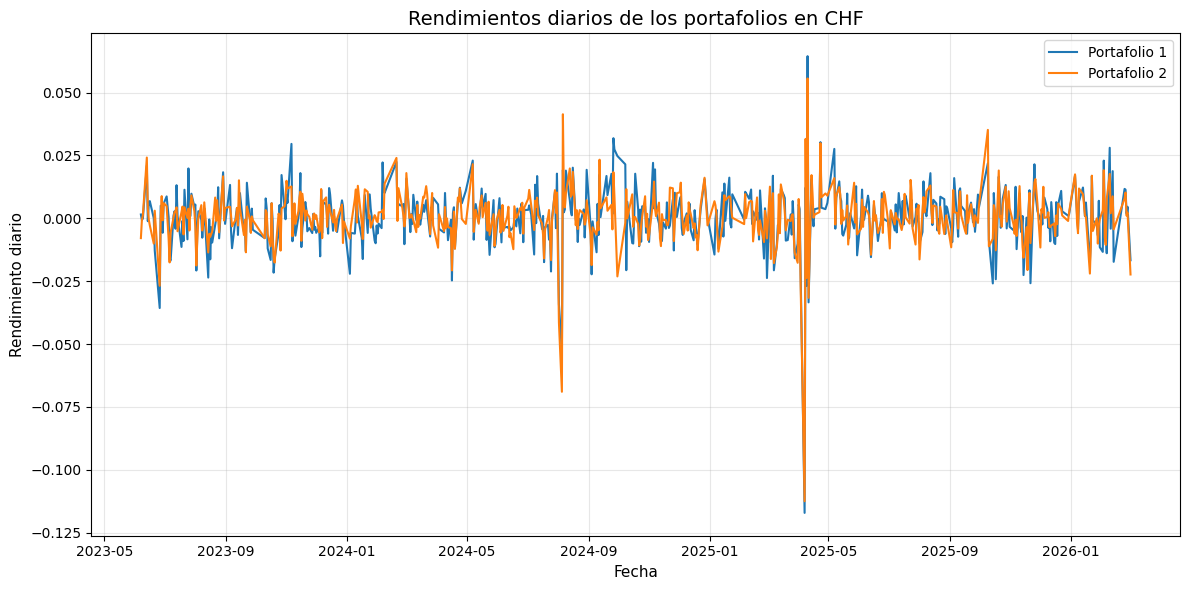

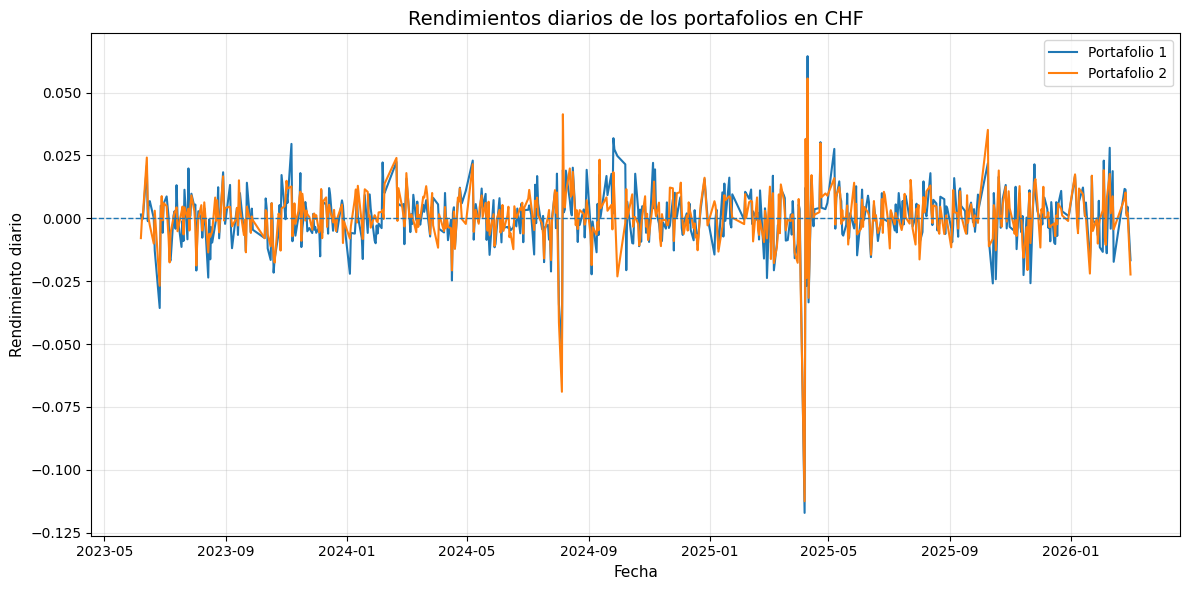

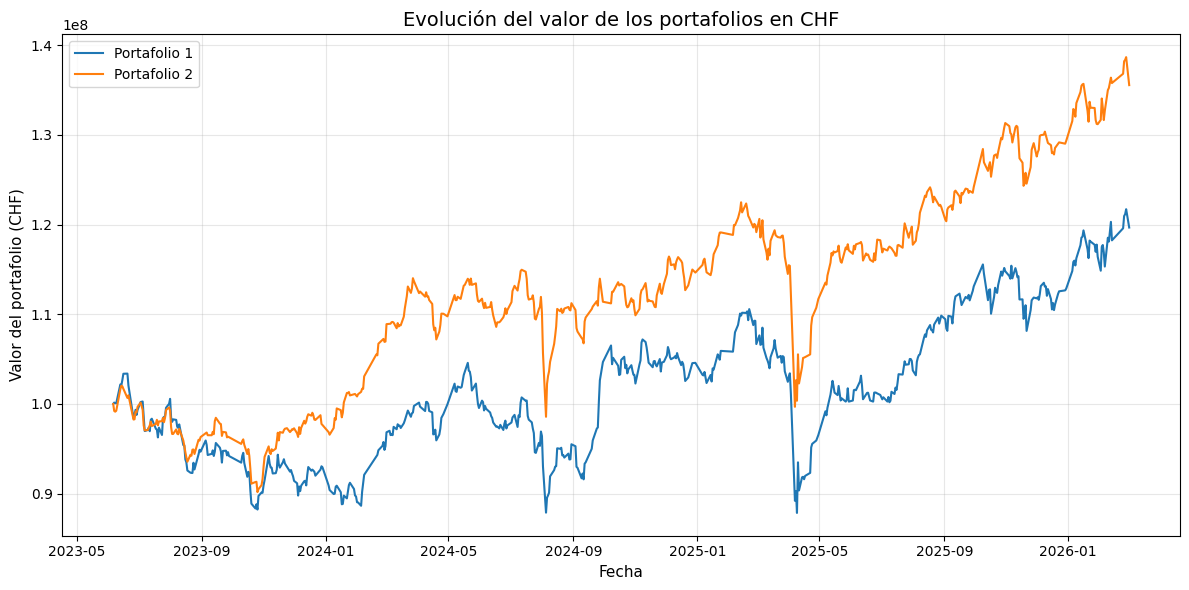

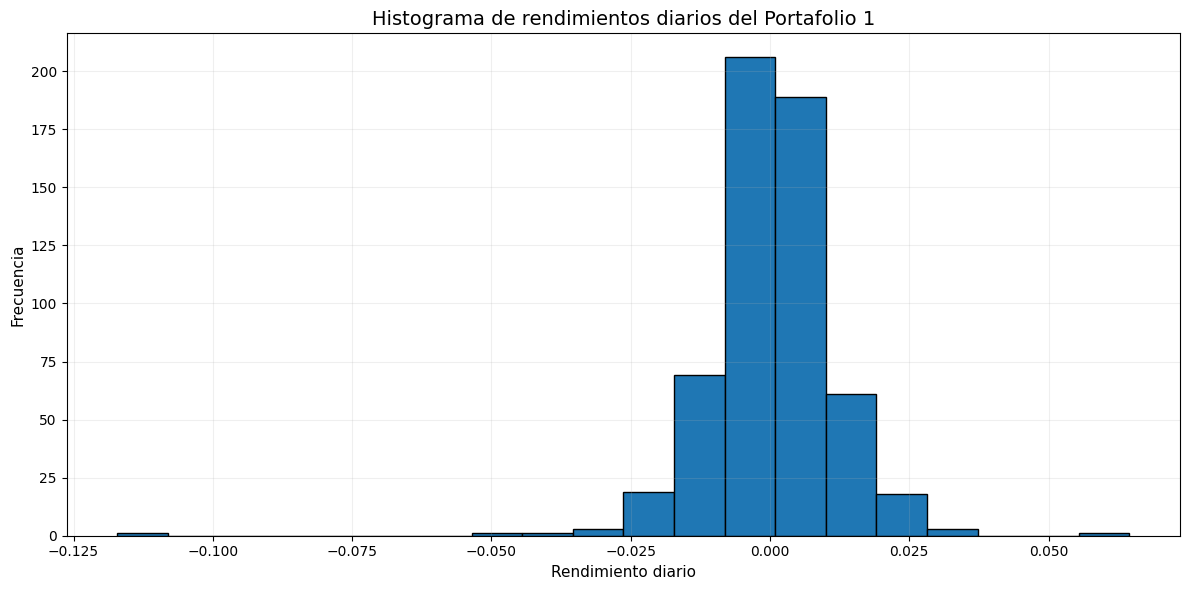

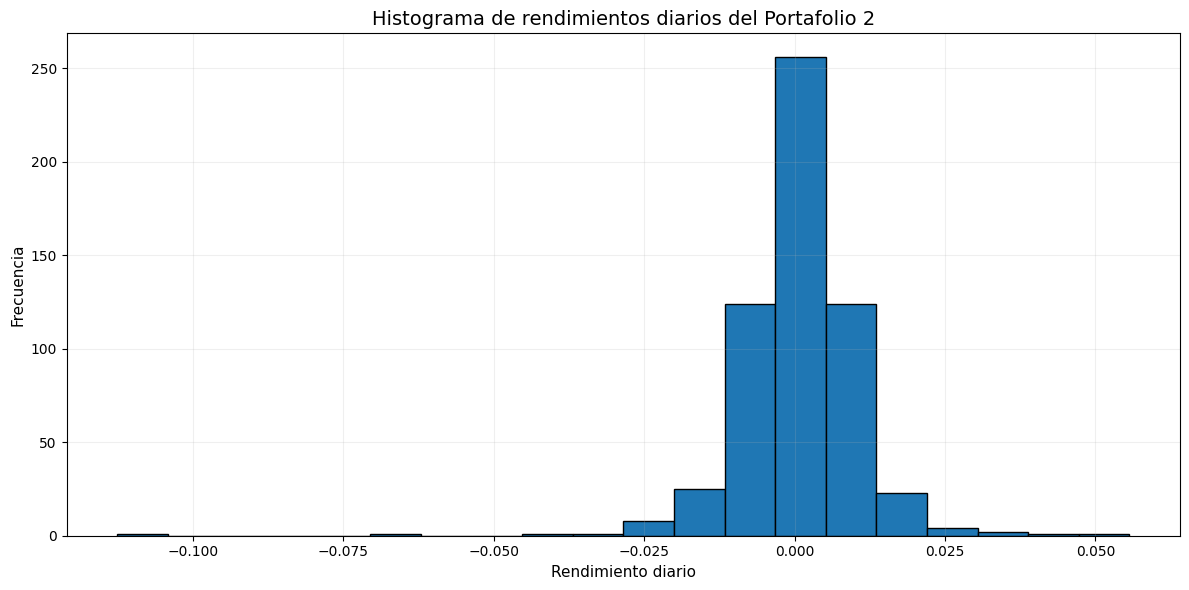

Gráficos guardados en la carpeta: C:\Users\pedro\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\5325A34FA8F91AF2FF7ADA33594115F1E57CA109\transfers\2026-10\graficos_ppt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

archivo_excel = "portafolios_riesgo_mercado_CHF.xlsx"
carpeta_salida = Path("graficos_ppt")
carpeta_salida.mkdir(exist_ok=True)

df_rend = pd.read_excel(archivo_excel, sheet_name="Rendimientos", index_col=0)
df_port = pd.read_excel(archivo_excel, sheet_name="Portafolios", index_col=0)

df_rend.index = pd.to_datetime(df_rend.index)
df_port.index = pd.to_datetime(df_port.index)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

# =========================
# Rendimientos diarios de ambos portafolios
# =========================
plt.figure()
plt.plot(df_rend.index, df_rend["PORTAFOLIO_1_REND"], label="Portafolio 1")
plt.plot(df_rend.index, df_rend["PORTAFOLIO_2_REND"], label="Portafolio 2")
plt.title("Rendimientos diarios de los portafolios en CHF")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento diario")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(carpeta_salida / "grafico_1_rendimientos_portafolios.png", dpi=300)
plt.show()

# =========================
# Rendimientos diarios de ambos portafolios con línea en cero
# =========================
plt.figure()
plt.plot(df_rend.index, df_rend["PORTAFOLIO_1_REND"], label="Portafolio 1")
plt.plot(df_rend.index, df_rend["PORTAFOLIO_2_REND"], label="Portafolio 2")
plt.axhline(0, linewidth=1, linestyle="--")
plt.title("Rendimientos diarios de los portafolios en CHF")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento diario")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(carpeta_salida / "grafico_2_rendimientos_con_cero.png", dpi=300)
plt.show()

# =========================
# Valor de los portafolios en CHF
# =========================
plt.figure()
plt.plot(df_port.index, df_port["PORTAFOLIO_1_VALOR_CHF"], label="Portafolio 1")
plt.plot(df_port.index, df_port["PORTAFOLIO_2_VALOR_CHF"], label="Portafolio 2")
plt.title("Evolución del valor de los portafolios en CHF")
plt.xlabel("Fecha")
plt.ylabel("Valor del portafolio (CHF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(carpeta_salida / "grafico_3_valor_portafolios.png", dpi=300)
plt.show()

# =========================
# Histograma del Portafolio 1
# =========================
plt.figure()
plt.hist(df_rend["PORTAFOLIO_1_REND"].dropna(), bins=20, edgecolor="black")
plt.title("Histograma de rendimientos diarios del Portafolio 1")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(carpeta_salida / "grafico_4_hist_portafolio_1.png", dpi=300)
plt.show()

# =========================
# Histograma del Portafolio 2
# =========================
plt.figure()
plt.hist(df_rend["PORTAFOLIO_2_REND"].dropna(), bins=20, edgecolor="black")
plt.title("Histograma de rendimientos diarios del Portafolio 2")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(carpeta_salida / "grafico_5_hist_portafolio_2.png", dpi=300)
plt.show()

print(f"Gráficos guardados en la carpeta: {carpeta_salida.resolve()}")